In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("House_Price_Linear_Regression_100.csv")

In [3]:
df.head(4)

,Area_sqft,Price_lakh
0,500,33.98
1,550,33.56
2,600,40.24
3,650,47.37


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area_sqft   100 non-null    int64  
 1   Price_lakh  100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [5]:
df.isnull().sum()

Area_sqft     0
Price_lakh    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [8]:
x

,Area_sqft
0,500
1,550
2,600
3,650
4,700
...,...
95,5250
96,5300
97,5350
98,5400


In [9]:
y

0      33.98
1      33.56
2      40.24
3      47.37
4      41.33
       ...  
95    285.43
96    296.98
97    299.56
98    301.03
99    302.58
Name: Price_lakh, Length: 100, dtype: float64

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [13]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(80, 1)
(80,)
(20, 1)
(20,)


In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [15]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.06]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area_sqft']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.038
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [17]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [0.05512193]
Intercept: 3.0384984513971176


In [21]:
df.head(5)

,Area_sqft,Price_lakh
0,500,33.98
1,550,33.56
2,600,40.24
3,650,47.37
4,700,41.33


In [27]:
print((model.coef_ * 700) + model.intercept_)

[41.62385272]


In [28]:
y_pred = model.predict(x_test)
y_pred

array([259.35549465, 176.67259265, 223.52623712, 154.62381878,
       151.86772205, 138.08723838,  91.23359392, 251.08720445,
        58.16043312,  30.59946578,  80.20920698, 113.28236778,
       231.79452732, 121.55065798, 278.64817178,  41.62385272,
       240.06281752, 242.81891425,  63.67262658, 116.03846452])

In [30]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)

    Actual   Predicted
0   257.16  259.355495
1   180.31  176.672593
2   225.81  223.526237
3   151.65  154.623819
4   145.11  151.867722
5   139.73  138.087238
6    92.34   91.233594
7   250.40  251.087204
8    56.68   58.160433
9    33.98   30.599466
10   76.46   80.209207
11  110.99  113.282368
12  240.07  231.794527
13  116.96  121.550658
14  279.49  278.648172
15   41.33   41.623853
16  240.94  240.062818
17  241.75  242.818914
18   65.71   63.672627
19  126.01  116.038465


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
mae = mean_absolute_error(y_test,y_pred)
print('MAE : ', mae)
mse = mean_squared_error(y_test, y_pred)
print('MSE : ',mse)
rmse = np.sqrt(mse)
print("RMSE : ",rmse)
r2 = r2_score(y_test,y_pred)
print("r2 : ", r2)

MAE :  3.007196860048295
MSE :  15.547510223101654
RMSE :  3.943033124778646
r2 :  0.997465132339364


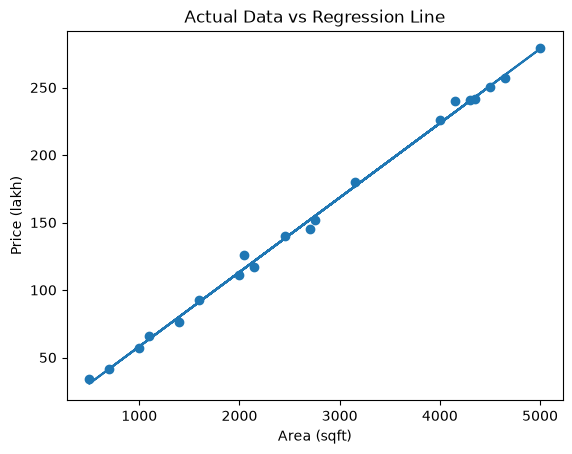

In [43]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred)
plt.xlabel("Area (sqft)")
plt.ylabel("Price (lakh)")
plt.title("Actual Data vs Regression Line")
plt.show()

In [45]:
prediction = model.predict([[3000]])

print("Predicted Price:", prediction[0], "lakh")

Predicted Price: 168.40430245001724 lakh


c:\Users\Test\Python_NIT\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [46]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.05512193466620671
Intercept: 3.0384984513971176


In [47]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [1]:
import joblib

loaded_model = joblib.load("house_price_model.pkl")

prediction = loaded_model.predict([[2500]])

print("Predicted Price:", prediction[0], "lakh")

Predicted Price: 140.8433351169139 lakh


c:\Users\Test\Python_NIT\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
